In [1]:
import os
import sys
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import matplotlib.dates as mdates
from shapely.geometry import Point
from sklearn.metrics import r2_score, mean_absolute_error
from geopy.distance import geodesic

### change directory to import more scripts
sys.path.append(str(Path().resolve().parents[1]))

from utils import tools
import generate_wind

if os.getcwd().split(os.sep)[-2] == 'evaluation':
    os.chdir('../..')

In [2]:
config = tools.load_config("configs/config_pv.yaml")

val_dir = 'data/Trianel_Benchmark'
synth_dir = os.path.join(config['data']['synth_dir'], 'solar', 'solar_hourly_age_soil')
results_dir = 'results/solar/real_parks'
geojsn_dir = 'misc/geoBoundaries-DE.geojson'
os.makedirs(results_dir, exist_ok=True)

features = config['features']

params = config['pv_params']

In [3]:
files = os.listdir(synth_dir)
station_files_synthetic = [f for f in files if 'parameter' not in f and f.endswith('.csv')]
station_files_synthetic.sort()
print(len(station_files_synthetic), 'station files in synthetic data found')
pv_params = pd.read_csv(os.path.join(synth_dir, 'pv_parameter.csv'), sep=';', dtype={"park_id": str})
all_pv_params = pd.read_csv(os.path.join(synth_dir, 'pv_parameter.csv'), sep=';', dtype={"park_id": str})

47 station files in synthetic data found


In [4]:
timestamp_col = 'timestamp'
dfs = []
for st in station_files_synthetic:
    station = pd.read_csv(os.path.join(synth_dir, st), sep=';')
    station[timestamp_col] = pd.to_datetime(station[timestamp_col], utc=True)
    station.set_index(timestamp_col, inplace=True)
    #station = station['2024-01-01':'2024-12-31']
    #metadata = pd.read_csv(os.path.join(path, md))
    dfs.append(station)

In [5]:
masterdata = pd.read_csv(os.path.join(val_dir, 'masterdata_solar_20240601.csv'), sep=';')
meterdata = pd.read_csv(os.path.join(val_dir, 'meterdata_solar_20240601.csv'), sep=';')
meterdata['Zeit'] = pd.to_datetime(meterdata['Zeit'], utc=True)
meterdata.set_index('Zeit', inplace=True)

In [6]:
m = folium.Map(location=[51.0, 10.0], zoom_start=6)

# --- 4. Punkte aus df1: rote Marker mit Tooltip ---
for _, row in all_pv_params.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        tooltip=f"Park ID: {row['park_id']}<br>Lat: {row['latitude']:.4f}, Lon: {row['longitude']:.4f}"
    ).add_to(m)

# --- 5. Punkte aus df2: blaue Marker mit Tooltip ---
for _, row in masterdata.iterrows():
    folium.CircleMarker(
        location=[row['Koordinaten Breite (WGS 84)'], row['Koordinaten Länge (WGS 84)']],
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.8,
        tooltip=f"Lat: {row['Koordinaten Breite (WGS 84)']:.4f}, \
                  Lon: {row['Koordinaten Länge (WGS 84)']:.4f}, \
                  Malo-ID: {row['Malo-ID']}, \
                  Park Name: {row['Parkname']}"
    ).add_to(m)
m.save('pv_parks.html')

In [7]:
meterdata = meterdata['2023-07-24':]
meterdata.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30049 entries, 2023-07-24 00:00:00+00:00 to 2024-06-01 00:00:00+00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   50304867557  30049 non-null  float64
 1   50330209905  30049 non-null  float64
 2   50413439940  0 non-null      float64
 3   50421446466  30049 non-null  float64
 4   50468907059  30049 non-null  float64
 5   50485503963  30045 non-null  float64
 6   50583222879  30045 non-null  float64
dtypes: float64(7)
memory usage: 1.8 MB


In [8]:
# get nearest stations to parks

columns = ['Malo-ID', 'Koordinaten Breite (WGS 84)', 'Koordinaten Länge (WGS 84)']
centroids = masterdata.groupby('Parkname')[columns].mean().reset_index()
centroids['Malo-ID'] = centroids['Malo-ID'].astype(str)
results = []
for _, park in centroids.iterrows():
    park_coords = (park['Koordinaten Breite (WGS 84)'], park['Koordinaten Länge (WGS 84)'])
    distances = all_pv_params.apply(
        lambda row: geodesic(park_coords, (row['latitude'], row['longitude'])).km, axis=1)
    nearest_station = all_pv_params.loc[distances.idxmin()]
    results.append({
        'park_name': park['Parkname'],
        'malo-id': str(park['Malo-ID']).split('.')[0],
        'park_id': nearest_station['park_id'],
        'distance_km': distances[distances.idxmin()],
        'altitude': nearest_station['altitude'],
        #'commissioning_date': nearest_station['commissioning_date']
    })
next_station = pd.DataFrame(results)
next_station.sort_values('distance_km')

,park_name,malo-id,park_id,distance_km,altitude
6,Solaranlage Quellenreuth,50330209905,15444,25.352984,593.0
7,Theinfeld,50304867557,03231,37.100071,450.0
5,SP SWP Thaleischweiler,50413439940,05426,42.250924,553.0
4,Prenzlau,50485503963,05142,48.892762,1.0
0,Georgsdorf,50583222879,07374,57.393507,46.0
1,Loitz - Alte Dübelfabrik,50468907059,05142,66.042857,1.0
2,Loitz - Hiddenhausener Str.,50468907059,05142,66.042857,1.0
3,PVA Uchtdorf,50421446466,03987,89.705583,81.0


In [9]:
cols = ['Parkname',
         'Installierte Leistung (kW)',
         'Azimut von (°)', 'Azimut bis (°)',
         'Neigung von (°)', 'Neigung bis (°)',
         'Koordinaten Breite (WGS 84)', 'Koordinaten Länge (WGS 84)']

masterdata[cols]#.to_csv('masterdata.csv', index=False)

,Parkname,Installierte Leistung (kW),Azimut von (°),Azimut bis (°),Neigung von (°),Neigung bis (°),Koordinaten Breite (WGS 84),Koordinaten Länge (WGS 84)
0,Loitz - Hiddenhausener Str.,4310.775,180.0,180.0,15.0,15.0,53.95091,13.128997
1,Loitz - Alte Dübelfabrik,1436.925,175.4,175.4,15.0,15.0,53.95091,13.128997
2,Solaranlage Quellenreuth,4479.830,184.0,184.0,25.0,25.0,48.35033,10.235206
3,PVA Uchtdorf,5952.960,180.0,180.0,15.0,15.0,52.41808,11.745617
4,SP SWP Thaleischweiler,9999.000,180.0,180.0,20.0,20.0,49.24581,7.575226
5,Theinfeld,9950.000,180.0,180.0,15.0,17.0,50.22798,10.351434
6,Theinfeld,2020.000,180.0,180.0,15.0,17.0,50.22798,10.351434
7,Prenzlau,13035.000,180.0,180.0,25.0,25.0,53.32000,13.880000
8,Georgsdorf,24720.000,180.0,180.0,25.0,25.0,52.59000,7.080000


In [ ]:
def plot_daily_load_profile(data: pd.DataFrame, date_of_interest: str = None, save_path: str = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    for date, day_df in data.groupby(data.index.date):
        if date_of_interest and str(date) != date_of_interest:
            continue
        fig, ax1 = plt.subplots(figsize=(8, 4))

        ax1.plot(day_df.index, day_df['synthetic'], color='red', label='Synthetic')
        ax1.plot(day_df.index, day_df['real'], color='blue', label='Real')

        ax1.set_xlabel('Time [UTC]')
        ax1.set_ylabel('Power [kW]')
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        ax2.plot(day_df.index, day_df['wind_speed_hub'], color='green', linestyle='--', label='Wind Speed')
        ax2.set_ylabel('Wind Speed [m/s]')
        ax2.legend(loc='upper right')

        # x-Achse formatieren: alle 3 Stunden, nur Uhrzeit
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        plt.title(f'Load and Wind Speed on {date}')
        plt.tight_layout()

        if save_path:
            filename = f"{save_path}/daily_{date}.png"
            plt.savefig(filename, dpi=300)
            plt.close()
        else:
            plt.show()

def plot_sum_produced(data: pd.Series, station_id: str = None, save_path: str = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    change_pct = 1 - data['synthetic'] / data['real']
    if change_pct < 0:
        color = 'green'
        change_text = f"{change_pct * 100:.1f}%"
    else:
        color = 'red'
        change_text = f"-{change_pct * 100:.1f}%"

    colors = ['darkorange', 'blue']
    fig, ax1 = plt.subplots(figsize=(3, 4))
    sns.barplot(x=data.index, y=data.values, ax=ax1)
    plt.ylabel('Produced Energy [MWh]')
    plt.xlabel('')

    synthetic_height = data['synthetic']
    ax1.text(
        x=0,  # Index "synthetic"
        y=synthetic_height + 5,  # etwas über dem Balken
        s=change_text,
        color=color,
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
    plt.tight_layout()

    if save_path:
        filename = f"{save_path}/sum_produced_energy_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()

def plot_error_distribution(data: pd.Series, station_id: str = None, save_path: str = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    sns.histplot(data, bins=50, stat='density')
    plt.xlabel('Real - Synthetic [kW]')
    plt.ylabel('Density')
    if save_path:
        filename = f"{save_path}/error_distribution_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()


def plot_power_bin_errors(data: pd.DataFrame, station_id: str = None, save_path = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    bin_size = 500
    df = data.copy()
    df.dropna(inplace=True)
    df['power_bin'] = df['real'].apply(lambda x: round(x / bin_size) * bin_size)
    plt.figure(figsize=(16, 6))
    sns.boxplot(
        data=df,
        x="power_bin",
        y="bias",
        showfliers=False,
        #palette=""
    )
    plt.xlabel("Power Bin [kW]")
    plt.ylabel("Real - Synthetic [kW]")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    if save_path:
        filename = f"{save_path}/power_bin_error_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()

In [ ]:
id_of_interest = None#'04745'
results = defaultdict(list)
for file, df in zip(station_files_synthetic, dfs):
    if len(file) == 15:
        station_id = file.split('_')[1][:5]
    else:
        station_id = file.split('_')[1][:7]
    # initialize paths
    daily_load_profile_path = os.path.join(results_dir, 'daily_profiles', station_id)
    sum_produced_path = os.path.join(results_dir, 'sum_produced')
    power_curve_path = os.path.join(results_dir, 'power_curve')
    error_distribution_path = os.path.join(results_dir, 'error_distribution')
    power_bin_error_path = os.path.join(results_dir, 'power_bin_error')
    malo_ids = next_station.loc[next_station.park_id == station_id[:5]]['malo-id']
    malo_id = malo_ids.iloc[0]
    if malo_id in results['malo-id'] and station_id not in results['station_id']:
        malo_id = malo_ids.iloc[1]
    elif malo_id in results['malo-id'] and station_id in results['station_id']:
        continue
    results['malo-id'].append(str(malo_id))
    results['station_id'].append(station_id)
    df_compare = pd.concat([df[:meterdata[malo_id].index[-1]], meterdata[malo_id]], axis=1)
    df_compare.rename(columns={malo_id: 'real'}, inplace=True)
    df_compare = df_compare.resample('30min', closed='left', label='left', origin='start').mean()
    # copy raw frame to filter outliers from real data
    df_lean = df_compare.copy()
    bias = df_lean['real'] - df_lean['synthetic']
    df_lean['bias'] = bias
    sum_produced = df_lean[['synthetic', 'real']].sum(axis=0) / 1000 / 2 # divide by 2 when resolution is 30 min
    # get metrics
    y_true = df_lean.dropna()['real']
    y_pred = df_lean.dropna()['synthetic']
    r_2 = r2_score(y_true=y_true, y_pred=y_pred)
    installed_capacity = 10
    y_true /= installed_capacity
    y_pred /= installed_capacity
    mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)
    results['r^2'].append(r_2)
    results['mae'].append(mae)
    if station_id == id_of_interest:
        break
    #plot_daily_load_profile(data=df_lean, save_path=daily_load_profile_path)
    plot_sum_produced(data=sum_produced, station_id=station_id, save_path=sum_produced_path)
    plot_error_distribution(data=bias, station_id=station_id, save_path=error_distribution_path)
    plot_power_bin_errors(data=df_lean, station_id=station_id, save_path=power_bin_error_path)
results = next_station.merge(pd.DataFrame(results), on='malo-id', how='left')

In [169]:
results

,park_name,malo-id,park_id,distance_km,altitude,station_id,r^2,mae
0,Barlt West,50454932698,01200,6.193933,3.0,01200,0.127962,0.1693
1,Eggstedt IV,50446515501,01200,14.666721,3.0,NaN,NaN,NaN
2,Jessin/Grimmen,50483800543,00298,33.268116,3.0,NaN,NaN,NaN
3,Lintern Wind GmbH & Co. KG,51443998641,07374,25.479156,46.0,NaN,NaN,NaN
4,SL Windpark Baumberge GmbH & Co. KG,51443998641,07374,25.667804,46.0,NaN,NaN,NaN
5,SL Windpark Issum GmbH & Co. KG,50646350971,01303,37.078687,150.0,NaN,NaN,NaN
6,SL Windpark Kengen GmbH & Co. KG,50646396058,01303,37.491446,150.0,NaN,NaN,NaN
7,SL Windpark Rheurdt GmbH & Co. KG,50646350997,01303,37.684676,150.0,NaN,NaN,NaN
8,"TWV, Windpark Vogelherd",51279106971,00282,36.767137,240.0,NaN,NaN,NaN
9,Trianel Windpark Eisleben (TWE),50082792290,00198,28.811703,164.0,NaN,NaN,NaN


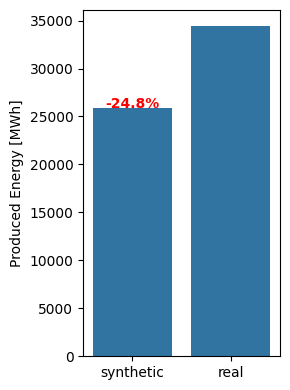

In [180]:
plot_sum_produced(data=sum_produced)

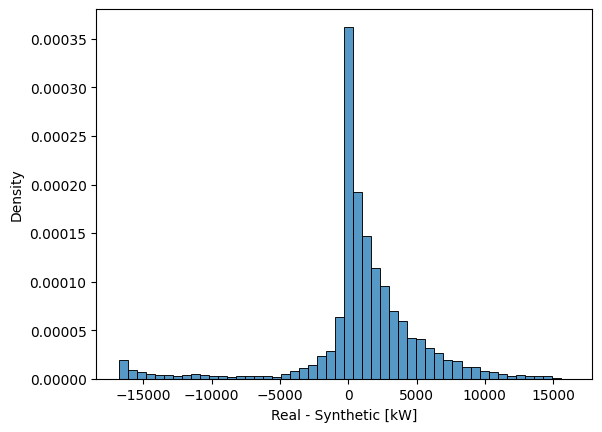

In [172]:
plot_error_distribution(data=bias)

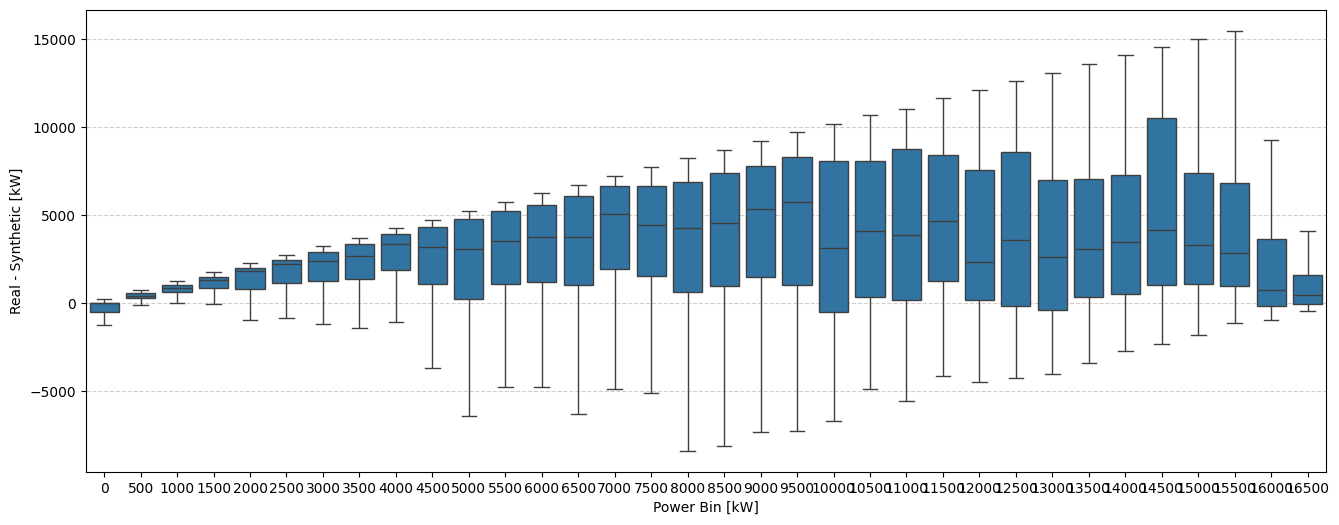

In [174]:
plot_power_bin_errors(data=df_lean)

In [175]:
print(f'R^2: {round(r_2 * 100, 2)} %')
print(f'MAE: {round(mae, 2) * 100} %')

R^2: 12.8 %
MAE: 17.0 %
